In [1]:
import os
print(os.getcwd())

/Users/apple


In [2]:
import pandas as pd
df=pd.read_csv(os.path.expanduser("~/Downloads/boston.csv"))
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


In [3]:
import pandas as pd
import numpy as  np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

In [4]:
print(df.shape)

(506, 14)


In [5]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    int64  
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    float64
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    506 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(12), int64(2)
memory usage: 55.5 KB
None


In [7]:
print(df.describe())

             CRIM          ZN       INDUS        CHAS         NOX          RM  \
count  506.000000  506.000000  506.000000  506.000000  506.000000  506.000000   
mean     3.613524   11.363636   11.136779    0.069170    0.554695    6.284634   
std      8.601545   23.322453    6.860353    0.253994    0.115878    0.702617   
min      0.006320    0.000000    0.460000    0.000000    0.385000    3.561000   
25%      0.082045    0.000000    5.190000    0.000000    0.449000    5.885500   
50%      0.256510    0.000000    9.690000    0.000000    0.538000    6.208500   
75%      3.677083   12.500000   18.100000    0.000000    0.624000    6.623500   
max     88.976200  100.000000   27.740000    1.000000    0.871000    8.780000   

              AGE         DIS         RAD         TAX     PTRATIO           B  \
count  506.000000  506.000000  506.000000  506.000000  506.000000  506.000000   
mean    68.574901    3.795043    9.549407  408.237154   18.455534  356.674032   
std     28.148861    2.1057

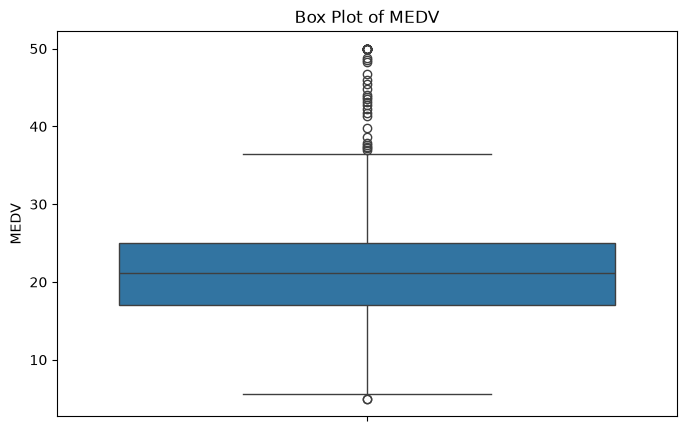

In [8]:
plt.figure(figsize=(8, 5))
sns.boxplot(y=df['MEDV'])
plt.title("Box Plot of MEDV")
plt.ylabel("MEDV")
plt.show()

In [9]:
Q1 = df['MEDV'].quantile(0.25)
Q3 = df['MEDV'].quantile(0.75)

print("Q1 =", Q1)
print("Q3 =", Q3)

Q1 = 17.025
Q3 = 25.0


In [10]:
IQR=Q3-Q1
print("IQR=",IQR)

IQR= 7.975000000000001


In [11]:
lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

print("Lower Limit =", lower_limit)
print("Upper Limit =", upper_limit)

Lower Limit = 5.0624999999999964
Upper Limit = 36.962500000000006


In [12]:
outliers_iqr = df[
    (df['MEDV'] < lower_limit) |
    (df['MEDV'] > upper_limit)
]

print("Outliers detected using IQR:")
print(outliers_iqr)

Outliers detected using IQR:
         CRIM    ZN  INDUS  CHAS     NOX     RM    AGE     DIS  RAD    TAX  \
97    0.12083   0.0   2.89     0  0.4450  8.069   76.0  3.4952    2  276.0   
98    0.08187   0.0   2.89     0  0.4450  7.820   36.9  3.4952    2  276.0   
157   1.22358   0.0  19.58     0  0.6050  6.943   97.4  1.8773    5  403.0   
161   1.46336   0.0  19.58     0  0.6050  7.489   90.8  1.9709    5  403.0   
162   1.83377   0.0  19.58     1  0.6050  7.802   98.2  2.0407    5  403.0   
163   1.51902   0.0  19.58     1  0.6050  8.375   93.9  2.1620    5  403.0   
166   2.01019   0.0  19.58     0  0.6050  7.929   96.2  2.0459    5  403.0   
179   0.05780   0.0   2.46     0  0.4880  6.980   58.4  2.8290    3  193.0   
180   0.06588   0.0   2.46     0  0.4880  7.765   83.3  2.7410    3  193.0   
182   0.09103   0.0   2.46     0  0.4880  7.155   92.2  2.7006    3  193.0   
186   0.05602   0.0   2.46     0  0.4880  7.831   53.6  3.1992    3  193.0   
190   0.09068  45.0   3.44     0  0

In [13]:
print("MEDV Outlier Values:")
print(outliers_iqr['MEDV'])

MEDV Outlier Values:
97     38.7
98     43.8
157    41.3
161    50.0
162    50.0
163    50.0
166    50.0
179    37.2
180    39.8
182    37.9
186    50.0
190    37.0
195    50.0
202    42.3
203    48.5
204    50.0
224    44.8
225    50.0
226    37.6
228    46.7
232    41.7
233    48.3
253    42.8
256    44.0
257    50.0
261    43.1
262    48.8
267    50.0
268    43.5
280    45.4
282    46.0
283    50.0
291    37.3
368    50.0
369    50.0
370    50.0
371    50.0
372    50.0
398     5.0
405     5.0
Name: MEDV, dtype: float64


In [14]:
print("Number of outliers =", len(outliers_iqr))

Number of outliers = 40


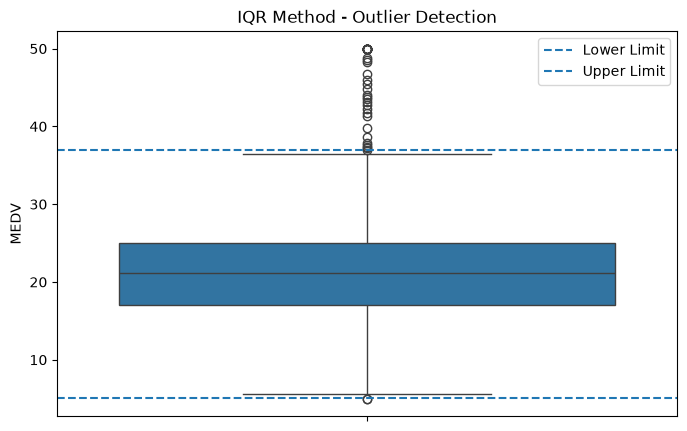

In [15]:
plt.figure(figsize=(8, 5))

sns.boxplot(y=df['MEDV'])

plt.axhline(lower_limit, linestyle='--', label='Lower Limit')
plt.axhline(upper_limit, linestyle='--', label='Upper Limit')

plt.title("IQR Method - Outlier Detection")
plt.ylabel("MEDV")
plt.legend()
plt.show()

In [16]:
df['MEDV_IQR_Capped'] = df['MEDV'].clip(
    lower=lower_limit,
    upper=upper_limit
)

print(df[['MEDV', 'MEDV_IQR_Capped']])

     MEDV  MEDV_IQR_Capped
0    24.0             24.0
1    21.6             21.6
2    34.7             34.7
3    33.4             33.4
4    36.2             36.2
..    ...              ...
501  22.4             22.4
502  20.6             20.6
503  23.9             23.9
504  22.0             22.0
505  11.9             11.9

[506 rows x 2 columns]


In [17]:
print(df[['MEDV', 'MEDV_IQR_Capped']].head(20))

    MEDV  MEDV_IQR_Capped
0   24.0             24.0
1   21.6             21.6
2   34.7             34.7
3   33.4             33.4
4   36.2             36.2
5   28.7             28.7
6   22.9             22.9
7   27.1             27.1
8   16.5             16.5
9   18.9             18.9
10  15.0             15.0
11  18.9             18.9
12  21.7             21.7
13  20.4             20.4
14  18.2             18.2
15  19.9             19.9
16  23.1             23.1
17  17.5             17.5
18  20.2             20.2
19  18.2             18.2


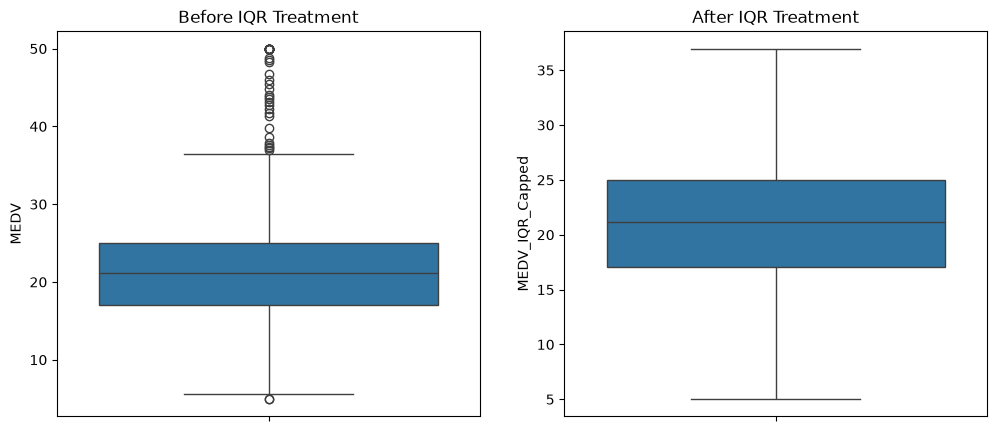

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(y=df['MEDV'], ax=axes[0])
axes[0].set_title("Before IQR Treatment")

sns.boxplot(y=df['MEDV_IQR_Capped'], ax=axes[1])
axes[1].set_title("After IQR Treatment")

plt.show()

In [19]:
df['Z_score'] = stats.zscore(df['MEDV'])

print(df[['MEDV', 'Z_score']])

     MEDV   Z_score
0    24.0  0.159686
1    21.6 -0.101524
2    34.7  1.324247
3    33.4  1.182758
4    36.2  1.487503
..    ...       ...
501  22.4 -0.014454
502  20.6 -0.210362
503  23.9  0.148802
504  22.0 -0.057989
505  11.9 -1.157248

[506 rows x 2 columns]


In [20]:
z_outliers = df[abs(df['Z_score']) > 3]

print("Outliers detected using Z-score:")
print(z_outliers)

Outliers detected using Z-score:
Empty DataFrame
Columns: [CRIM, ZN, INDUS, CHAS, NOX, RM, AGE, DIS, RAD, TAX, PTRATIO, B, LSTAT, MEDV, MEDV_IQR_Capped, Z_score]
Index: []


In [21]:
print("Number of Z-score outliers =", len(z_outliers))

Number of Z-score outliers = 0


In [22]:
df['Z_Outlier'] = abs(df['Z_score']) > 3

print(df[['MEDV', 'Z_score', 'Z_Outlier']])

     MEDV   Z_score  Z_Outlier
0    24.0  0.159686      False
1    21.6 -0.101524      False
2    34.7  1.324247      False
3    33.4  1.182758      False
4    36.2  1.487503      False
..    ...       ...        ...
501  22.4 -0.014454      False
502  20.6 -0.210362      False
503  23.9  0.148802      False
504  22.0 -0.057989      False
505  11.9 -1.157248      False

[506 rows x 3 columns]
